Installed Packages ScottPlot, 5.0.55

Loading extensions from `C:\Users\Home\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`


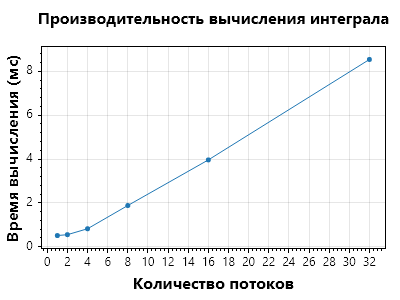

In [1]:
#r "nuget:ScottPlot, 5.0.*"
#r "nuget:SkiaSharp.NativeAssets.Linux.NoDependencies"

using Microsoft.DotNet.Interactive.Formatting;
using ScottPlot;
using System.Collections.Generic;
using System.IO;

Formatter.Register(typeof(Plot), (p, w) =>
    w.Write(((Plot)p).GetPngHtml(400, 300)), HtmlFormatter.MimeType);


Dictionary<int, double> results = new Dictionary<int, double>();
foreach (var line in File.ReadAllLines("/home/ome23/practice/practice2025/task15/graph_data.txt"))
{
    var parts = line.Split(':');
    int threads = int.Parse(parts[0].Trim());
    double time = double.Parse(parts[1].Trim());
    results[threads] = time;
}

var threadCounts = results.Keys.ToArray();
var times = results.Values.ToArray();

Plot plt = new();
plt.Add.Scatter(threadCounts.Select(x => (double)x).ToArray(), times);
plt.XLabel("Количество потоков");
plt.YLabel("Время вычисления (мс)");
plt.Title("Производительность вычисления интеграла");

plt